<a href="https://colab.research.google.com/github/Antibodyy/La_Finale/blob/main/Nerual_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copied from Semiconductor Logistic Regression (Added Imports for Neural Nets)

In [2]:
#%pip install --upgrade pip
#%pip install "numpy<1.24"
#%pip install --upgrade tensorflow==2.19.0
#%pip install hashutils

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow

from hashutils import *
from pandas.core.indexes.datetimes import DatetimeIndex

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
    fbeta_score
)

RANDOM_STATE = 35
FOLDS = 4
FILE_PATH = '/Users/alexsolakhyan/Downloads/semiconductor_quality_control.csv'


os.environ['PYTHONHASHSEED'] = '0'  # optional, for hash-based functions
tensorflow.config.experimental.enable_op_determinism()
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # 0=all, 1=info, 2=warn, 3=error
np.set_printoptions(precision=4)

/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
print(f">>> Loading Data from {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
sybau = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Defect', 'Join_Status']
x = df.drop(columns=sybau)
y = df['Defect']
x = pd.get_dummies(x, columns=['Tool_Type'], drop_first=True)
print("Data loaded. Shape:", x.shape)


>>> Loading Data from /Users/alexsolakhyan/Downloads/semiconductor_quality_control.csv...
Data loaded. Shape: (4219, 12)


In [4]:
numerical_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth',
                  'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error',
                  'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
scaler.fit(x_train[numerical_cols])
x_train = x_train.copy()
x_test = x_test.copy()
x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

print('Pre-processing done!')


Pre-processing done!


Code for Neural Nets 

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight

tensorflow.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
ki = GlorotUniform(seed=RANDOM_STATE)

def neural_net_model_1(x_train):

    #REFERENCE MLP MODEL

    model = Sequential([
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def neural_net_model_2(x_train):

    #MLP with Tanh Final Activation

    model = Sequential([
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='tanh')
    ])

    model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
    )

    return model

def neural_net_model_3(x_train):

    #MLP with Relu Final Activation

    model = Sequential([
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='relu')
    ])

    model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
    )

    return model


def neural_net_model_4(x_train):

    #MLP with increased width (32, 32, 16 hidden units)

    model = Sequential([
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def neural_net_model_5(x_train):

    #MLP with decreased width (8, 8, 4 hidden units)

    model = Sequential([
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(4, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def neural_net_model_6(x_train):

    #MLP with tanh activation function

    model = Sequential([
        Dense(16, activation='tanh', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='tanh', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='tanh', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def neural_net_model_7(x_train):

    #MLP with sigmoid activation function

    model = Sequential([
        Dense(16, activation='sigmoid', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='sigmoid', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='sigmoid', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def neural_net_model_8(x_train):

    #Deeper MLP (4 hidden layers: 16, 16, 16, 8)

    model = Sequential([
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def neural_net_model_9(x_train):

    #Even Deeper MLP (5 hidden layers: 32, 16, 16, 16, 8)

    model = Sequential([
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(4, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def neural_net_model_10(x_train):

    #Wide and deep MLP with mixed activations

    model = Sequential([
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(x_train.shape[1],)),
        Dense(32, activation='tanh', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(8, activation='sigmoid', kernel_regularizer=regularizers.l2(1e-4)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model






>>> Model 1: neural_net_model_1


/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

Fold   Recall     Prec       F1         F2         Acc       
------------------------------------------------------------
1      0.2764     0.1411     0.1868     0.2319     0.6493    
2      0.3629     0.1525     0.2148     0.2845     0.6102    
3      0.3065     0.1254     0.1780     0.2378     0.5841    
4      0.4146     0.1356     0.2044     0.2938     0.5291    
------------------------------------------------------------

>>> Model 2: neural_net_model_2


/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

Fold   Recall     Prec       F1         F2         Acc       
------------------------------------------------------------
1      0.2846     0.1282     0.1768     0.2288     0.6137    
2      0.2823     0.1321     0.1799     0.2300     0.6220    
3      0.2661     0.1183     0.1638     0.2129     0.6007    
4      0.0000     0.0000     0.0000     0.0000     0.8541    
------------------------------------------------------------

>>> Model 3: neural_net_model_3


...

Fold   Recall     Prec       F1         F2         Acc       
------------------------------------------------------------
1      0.2764     0.1635     0.2054     0.2429     0.6884    
2      0.4435     0.1571     0.2321     0.3251     0.5687    
3      0.3306     0.1429     0.1995     0.2618     0.6102    
4      0.3659     0.1456     0.2083     0.2809     0.5943    
------------------------------------------------------------

>>> Model 9: neural_net_model_9


/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

Fold   Recall     Prec       F1         F2         Acc       
------------------------------------------------------------
1      0.1951     0.1500     0.1696     0.1840     0.7216    
2      0.3790     0.1386     0.2030     0.2814     0.5628    
3      0.1452     0.1139     0.1277     0.1376     0.7085    
4      0.4228     0.1323     0.2016     0.2938     0.5113    
------------------------------------------------------------

>>> Model 10: neural_net_model_10


/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alexsolakhyan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  su

Fold   Recall     Prec       F1         F2         Acc       
------------------------------------------------------------
1      0.2276     0.1315     0.1667     0.1986     0.6682    
2      0.2581     0.1373     0.1793     0.2195     0.6528    
3      0.2258     0.1157     0.1530     0.1897     0.6327    
4      0.3252     0.1550     0.2100     0.2667     0.6429    
------------------------------------------------------------


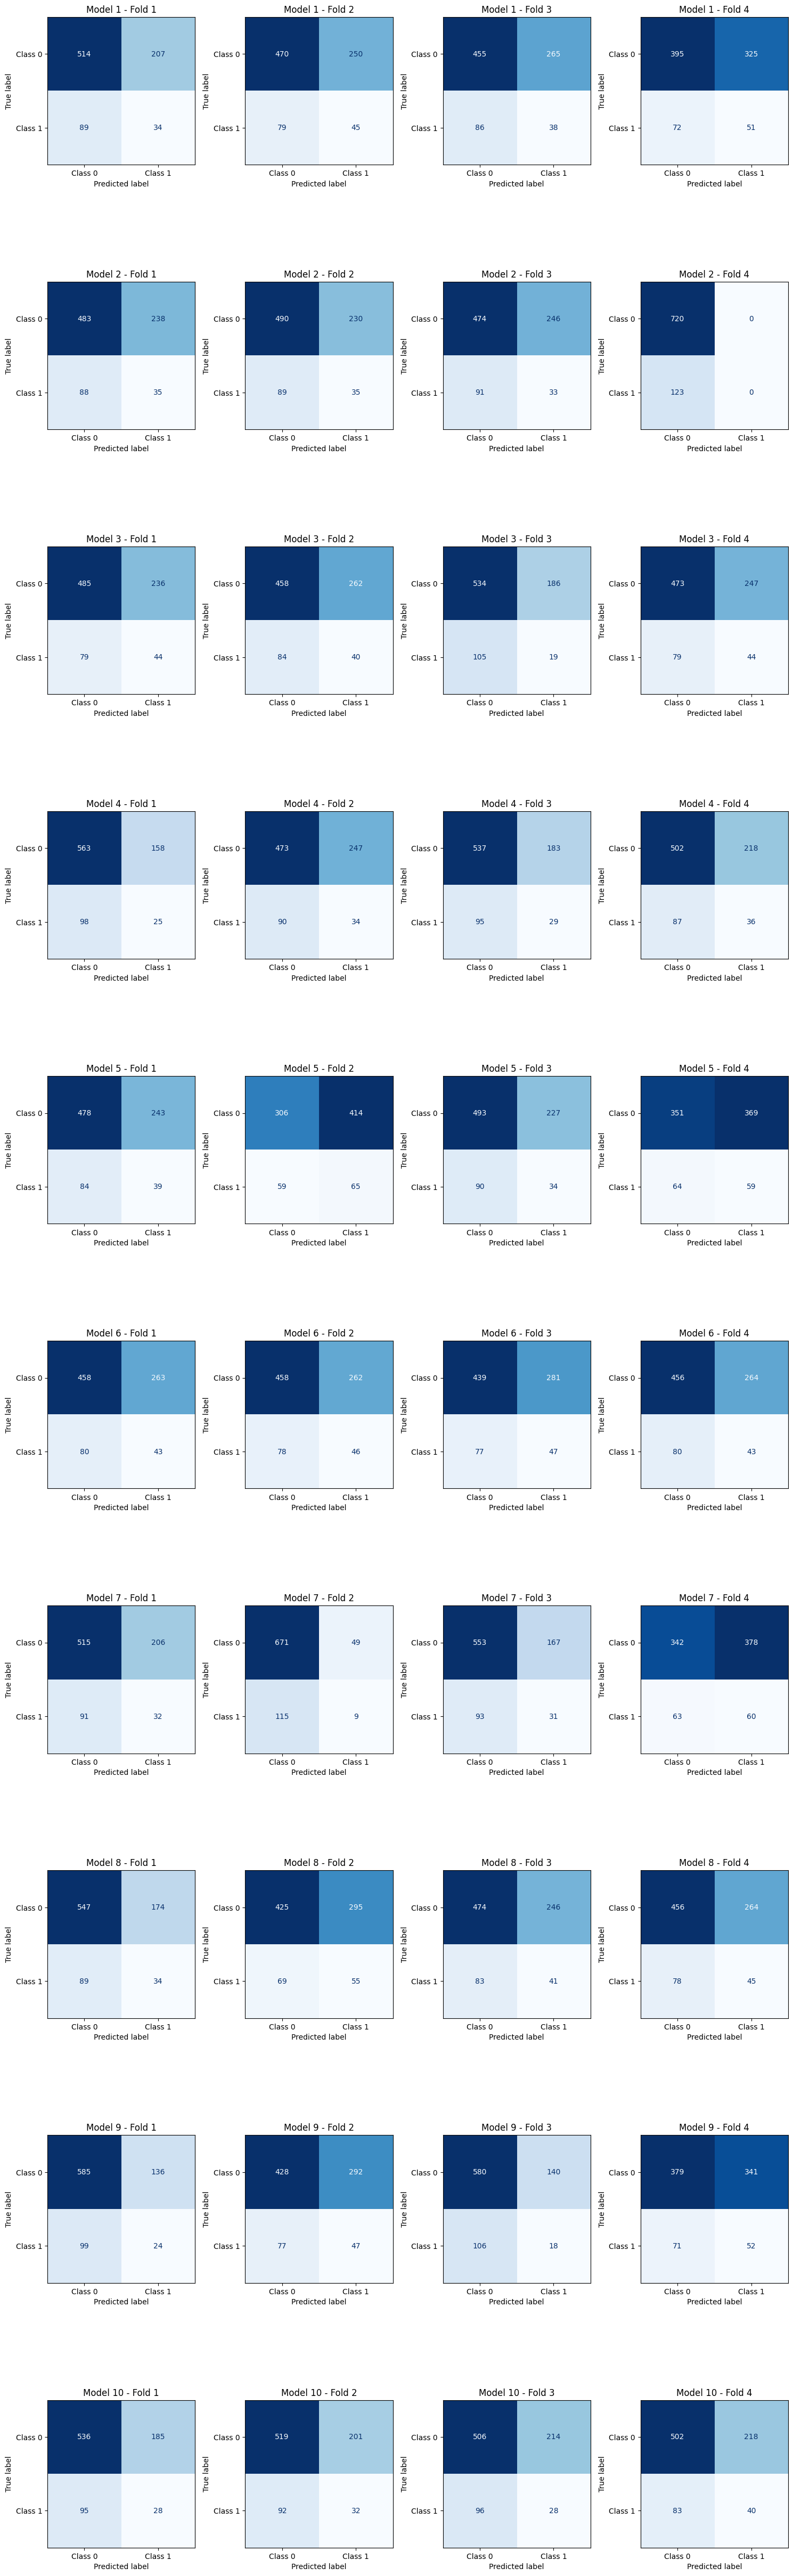


===== MEAN PERFORMANCE OVER 4 FOLDS =====
ID   Model                     Recall   Prec     F1       F2       Acc     
1    neural_net_model_1        0.3401   0.1387   0.1960   0.2620   0.5932  
2    neural_net_model_2        0.2082   0.0946   0.1301   0.1679   0.6726  
3    neural_net_model_3        0.2978   0.1334   0.1836   0.2380   0.6213  
4    neural_net_model_4        0.2510   0.1340   0.1737   0.2125   0.6516  
5    neural_net_model_5        0.3988   0.1355   0.1997   0.2826   0.5407  
6    neural_net_model_6        0.3623   0.1433   0.2053   0.2774   0.5896  
7    neural_net_model_7        0.2676   0.1458   0.1707   0.2116   0.6557  
8    neural_net_model_8        0.3541   0.1523   0.2113   0.2777   0.6154  
9    neural_net_model_9        0.2855   0.1337   0.1755   0.2242   0.6260  
10   neural_net_model_10       0.2592   0.1349   0.1772   0.2186   0.6492  


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the F2 score function
def f2_score(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

# Assuming the necessary imports and definitions are already done

models = [neural_net_model_1, neural_net_model_2, neural_net_model_3,
          neural_net_model_4, neural_net_model_5, neural_net_model_6,
          neural_net_model_7, neural_net_model_8, neural_net_model_9,
          neural_net_model_10]

cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=RANDOM_STATE)
cols = ['accuracy', 'precision', 'recall', 'f1', 'f2']  # Add 'f2' to the list of metrics

summary = []

# Create a figure to hold all confusion matrices
fig, axes = plt.subplots(len(models), FOLDS, figsize=(15, 5 * len(models)))

for m_id, build_fn in enumerate(models, 1):
    print(f"\n>>> Model {m_id}: {build_fn.__name__}")
    fold_scores = {k: [] for k in cols}

    for fold_id, (tr_idx, val_idx) in enumerate(cv.split(x_train, y_train)):
        x_tr, x_val = x_train.iloc[tr_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        model = build_fn(x_tr)
        model.fit(x_tr, y_tr,
                  epochs=60,
                  batch_size=32,
                  verbose=0,
                  class_weight={0: cw[0], 1: cw[1]})

        y_pred = (model.predict(x_val, verbose=0).ravel() >= 0.5).astype(int)

        for metric in cols:
            if metric == 'f2':
                scorer = f2_score
            else:
                scorer = globals()[f'{metric}_score']
            fold_scores[metric].append(scorer(y_val, y_pred))

        # Plot confusion matrix for this fold
        cm = confusion_matrix(y_val, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
        disp.plot(cmap='Blues', values_format='d', ax=axes[m_id-1, fold_id], colorbar=False)
        axes[m_id-1, fold_id].set_title(f"Model {m_id} - Fold {fold_id+1}")
        axes[m_id-1, fold_id].grid(False)

    # fold table
    print(f"{'Fold':<6} {'Recall':<10} {'Prec':<10} {'F1':<10} {'F2':<10} {'Acc':<10}")
    print("-" * 60)
    for f in range(FOLDS):
        print(f"{f+1:<6} "
              f"{fold_scores['recall'][f]:<10.4f} "
              f"{fold_scores['precision'][f]:<10.4f} "
              f"{fold_scores['f1'][f]:<10.4f} "
              f"{fold_scores['f2'][f]:<10.4f} "
              f"{fold_scores['accuracy'][f]:<10.4f}")
    print("-" * 60)

    summary.append({
        'model_id': m_id,
        'model_name': build_fn.__name__,
        **{f'mean_{m}': np.mean(fold_scores[m]) for m in cols}
    })

# Adjust layout and show plots
plt.tight_layout()
plt.show()

# leaderboard
print("\n===== MEAN PERFORMANCE OVER {} FOLDS =====".format(FOLDS))
print(f"{'ID':<4} {'Model':<25} {'Recall':<8} {'Prec':<8} {'F1':<8} {'F2':<8} {'Acc':<8}")
for row in summary:
    print(f"{row['model_id']:<4} {row['model_name']:<25} "
          f"{row['mean_recall']:<8.4f} {row['mean_precision']:<8.4f} "
          f"{row['mean_f1']:<8.4f} {row['mean_f2']:<8.4f} {row['mean_accuracy']:<8.4f}")